# StockEmotions Exploratory Analysis

This notebook performs basic exploratory analysis of the local StockEmotions splits in `data/stockemo/`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/marketmood-matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 80)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "stockemo"

split_paths = {
    "train": DATA_DIR / "train_stockemo.csv",
    "validation": DATA_DIR / "val_stockemo.csv",
    "test": DATA_DIR / "test_stockemo.csv",
}

split_paths

{'train': PosixPath('/Users/hanwang/projects/aipi540-marketmood/data/stockemo/train_stockemo.csv'),
 'validation': PosixPath('/Users/hanwang/projects/aipi540-marketmood/data/stockemo/val_stockemo.csv'),
 'test': PosixPath('/Users/hanwang/projects/aipi540-marketmood/data/stockemo/test_stockemo.csv')}

## Load Splits And Validate Schema

In [2]:
required_columns = {
    "id",
    "date",
    "ticker",
    "emo_label",
    "senti_label",
    "original",
    "processed",
}

frames = {}
for split, path in split_paths.items():
    frame = pd.read_csv(path)
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{split} is missing expected columns: {sorted(missing)}")
    frame = frame.copy()
    frame["split"] = split
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
    frames[split] = frame

stockemo = pd.concat(frames.values(), ignore_index=True)
stockemo["ticker"] = stockemo["ticker"].astype(str).str.upper().str.strip()

split_summary = (
    stockemo.groupby("split")
    .agg(
        rows=("id", "size"),
        unique_ids=("id", "nunique"),
        unique_tickers=("ticker", "nunique"),
        min_date=("date", "min"),
        max_date=("date", "max"),
    )
    .sort_index()
)

split_summary

,rows,unique_ids,unique_tickers,min_date,max_date
split,,,,,
test,1000,1000,31,2020-01-02,2020-12-31
train,8000,8000,37,2020-01-01,2020-12-31
validation,1000,1000,33,2020-01-02,2020-12-31


Split is good, perhaps focus on a few ticker to start, top 10?

In [3]:
schema_summary = pd.DataFrame(
    {
        "dtype": stockemo.dtypes.astype(str),
        "missing_count": stockemo.isna().sum(),
        "missing_rate": stockemo.isna().mean().round(4),
        "n_unique": stockemo.nunique(dropna=True),
    }
)

schema_summary

,dtype,missing_count,missing_rate,n_unique
id,int64,0,0.0,10000
date,datetime64[us],0,0.0,341
ticker,str,0,0.0,37
emo_label,str,0,0.0,12
senti_label,str,0,0.0,2
original,str,0,0.0,10000
processed,str,0,0.0,10000
split,str,0,0.0,3


No missing data!

In [4]:
duplicate_summary = pd.Series(
    {
        "duplicate_ids": stockemo["id"].duplicated().sum(),
        "duplicate_original_text": stockemo["original"].duplicated().sum(),
        "rows_with_unparsed_date": stockemo["date"].isna().sum(),
        "empty_original_text": stockemo["original"].fillna("").str.strip().eq("").sum(),
        "empty_processed_text": stockemo["processed"].fillna("").str.strip().eq("").sum(),
    }
)

duplicate_summary.to_frame("count")

,count
duplicate_ids,0
duplicate_original_text,0
rows_with_unparsed_date,0
empty_original_text,0
empty_processed_text,0


Data is clean!

## Ticker Coverage

In [5]:
ticker_counts = stockemo["ticker"].value_counts()
ticker_by_split = pd.crosstab(stockemo["ticker"], stockemo["split"])

display(ticker_counts.head(20).to_frame("posts"))
display(ticker_by_split.loc[ticker_counts.head(20).index])

,posts
ticker,
TSLA,4341
AAPL,1721
BA,919
DIS,432
AMZN,407
MSFT,271
CCL,264
BABA,239
FB,204


split,test,train,validation
ticker,,,
TSLA,426,3463,452
AAPL,167,1395,159
BA,88,730,101
DIS,41,355,36
AMZN,39,319,49
MSFT,35,208,28
CCL,33,211,20
BABA,28,192,19
FB,22,158,24


Top 10 looks good.

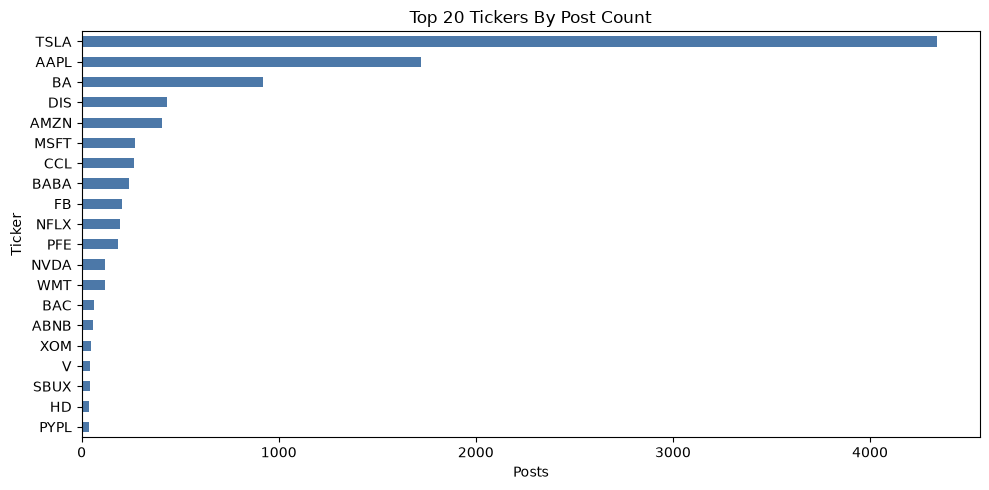

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ticker_counts.head(20).sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Top 20 Tickers By Post Count")
ax.set_xlabel("Posts")
ax.set_ylabel("Ticker")
plt.tight_layout()

## Sentiment And Emotion Labels

These labels can support analysis, but they should not be treated as live inference features unless a separate model predicts them first.

In [7]:
sentiment_counts = pd.crosstab(stockemo["senti_label"], stockemo["split"], margins=True)
emotion_counts = pd.crosstab(stockemo["emo_label"], stockemo["split"], margins=True)

display(sentiment_counts)
display(emotion_counts)

split,test,train,validation,All
senti_label,,,,
bearish,445,3618,463,4526
bullish,555,4382,537,5474
All,1000,8000,1000,10000


split,test,train,validation,All
emo_label,,,,
ambiguous,87,698,86,871
amusement,83,652,83,818
anger,38,309,39,386
anxiety,134,1099,133,1366
belief,89,728,91,908
confusion,60,489,60,609
depression,19,166,20,205
disgust,121,1037,121,1279
excitement,146,1092,148,1386


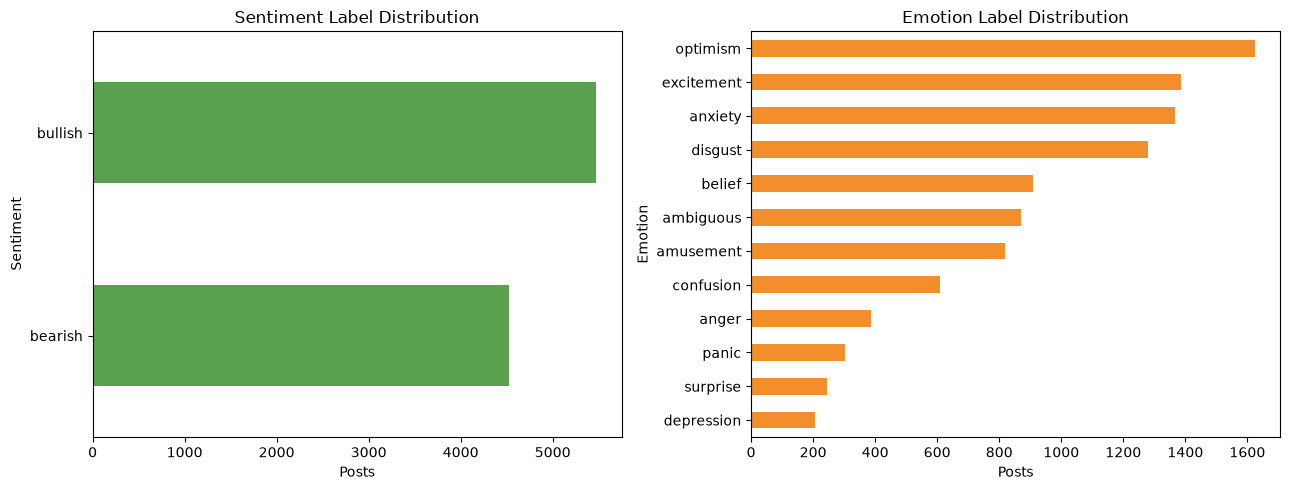

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stockemo["senti_label"].value_counts().sort_values().plot(
    kind="barh", ax=axes[0], color="#59A14F"
)
axes[0].set_title("Sentiment Label Distribution")
axes[0].set_xlabel("Posts")
axes[0].set_ylabel("Sentiment")

stockemo["emo_label"].value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="#F28E2B"
)
axes[1].set_title("Emotion Label Distribution")
axes[1].set_xlabel("Posts")
axes[1].set_ylabel("Emotion")

plt.tight_layout()

In [9]:
emotion_sentiment = pd.crosstab(
    stockemo["emo_label"],
    stockemo["senti_label"],
    normalize="index",
).round(3)

emotion_sentiment

senti_label,bearish,bullish
emo_label,,
ambiguous,0.612,0.388
amusement,0.372,0.628
anger,0.790,0.210
anxiety,0.622,0.378
belief,0.226,0.774
confusion,0.516,0.484
depression,0.688,0.312
disgust,0.571,0.429
excitement,0.249,0.751


## Text Length And Social-Media Markers

In [10]:
text_eda = stockemo.copy()
text_eda["original"] = text_eda["original"].fillna("").astype(str)
text_eda["processed"] = text_eda["processed"].fillna("").astype(str)
text_eda["original_char_count"] = text_eda["original"].str.len()
text_eda["original_word_count"] = text_eda["original"].str.split().str.len()
text_eda["processed_char_count"] = text_eda["processed"].str.len()
text_eda["cashtag_count"] = text_eda["original"].str.count(r"\$[A-Za-z][A-Za-z0-9._-]*")
text_eda["has_non_ascii"] = text_eda["original"].map(lambda value: any(ord(char) > 127 for char in value))

length_summary = (
    text_eda.groupby("split")[["original_char_count", "original_word_count", "cashtag_count", "has_non_ascii"]]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

length_summary

original_char_count                 original_word_count             \
                          mean median min  max                mean median min   
split                                                                           
test                     79.01   68.0  21  251               15.20   13.0   4   
train                    79.24   66.0  19  256               15.29   13.0   5   
validation               78.03   64.0  25  249               15.06   13.0   5   

               cashtag_count                has_non_ascii                      
           max          mean median min max          mean median    min   max  
split                                                                          
test        46           1.0    1.0   1   1           1.0    1.0   True  True  
train       56           1.0    1.0   1   1           1.0    1.0  False  True  
validation  49           1.0    1.0   1   1           1.0    1.0   True  True

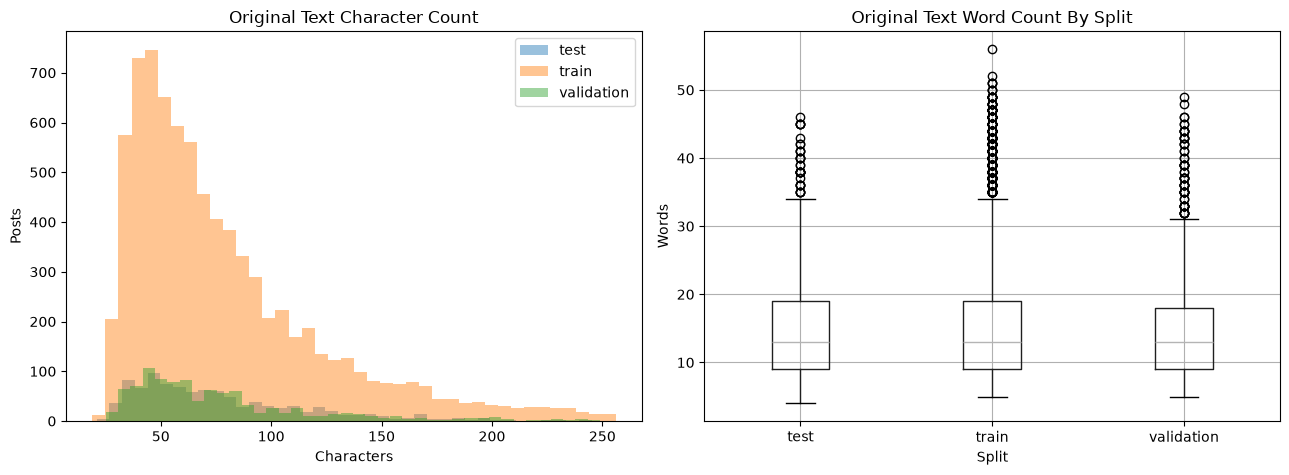

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for split, group in text_eda.groupby("split"):
    axes[0].hist(group["original_char_count"], bins=40, alpha=0.45, label=split)
axes[0].set_title("Original Text Character Count")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Posts")
axes[0].legend()

text_eda.boxplot(column="original_word_count", by="split", ax=axes[1])
axes[1].set_title("Original Text Word Count By Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Words")
fig.suptitle("")

plt.tight_layout()

In [12]:
marker_summary = pd.DataFrame(
    {
        "posts": text_eda.groupby("split").size(),
        "posts_with_cashtag": text_eda.assign(has_cashtag=text_eda["cashtag_count"].gt(0)).groupby("split")["has_cashtag"].sum(),
        "posts_with_non_ascii": text_eda.groupby("split")["has_non_ascii"].sum(),
        "avg_cashtag_count": text_eda.groupby("split")["cashtag_count"].mean().round(3),
    }
)
marker_summary["cashtag_rate"] = (marker_summary["posts_with_cashtag"] / marker_summary["posts"]).round(3)
marker_summary["non_ascii_rate"] = (marker_summary["posts_with_non_ascii"] / marker_summary["posts"]).round(3)

marker_summary

,posts,posts_with_cashtag,posts_with_non_ascii,avg_cashtag_count,cashtag_rate,non_ascii_rate
split,,,,,,
test,1000,1000,1000,1.0,1.0,1.0
train,8000,8000,7999,1.0,1.0,1.0
validation,1000,1000,1000,1.0,1.0,1.0


## Date Coverage

Date coverage is inspected here before any trading-day alignment. Later phases will map post dates to ticker-specific trading dates and avoid future-price leakage.

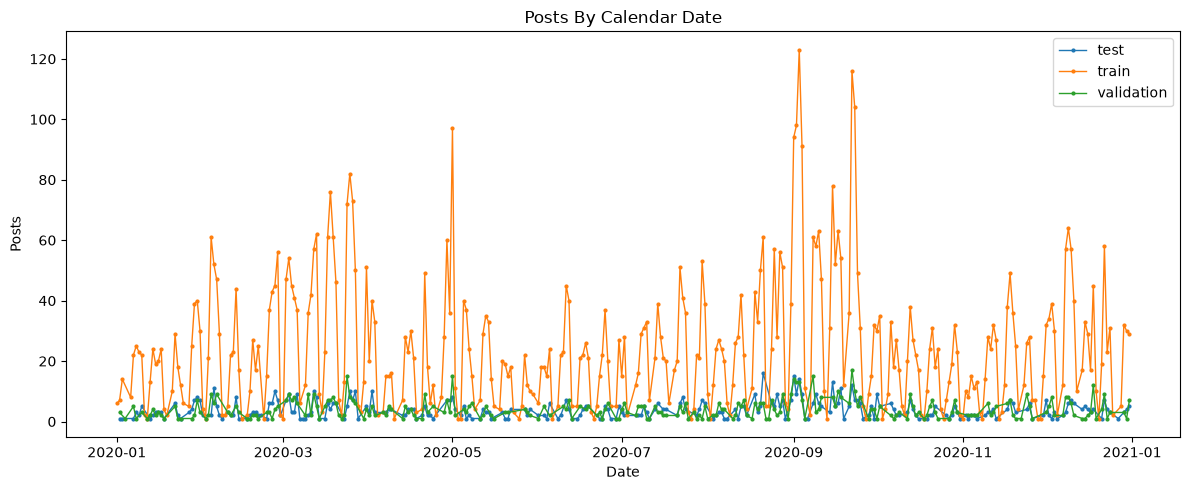

In [13]:
posts_by_date = stockemo.groupby(["split", "date"]).size().rename("posts").reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for split, group in posts_by_date.groupby("split"):
    ax.plot(group["date"], group["posts"], marker="o", linewidth=1, markersize=2, label=split)
ax.set_title("Posts By Calendar Date")
ax.set_xlabel("Date")
ax.set_ylabel("Posts")
ax.legend()
plt.tight_layout()

## Representative Examples

In [14]:
example_columns = ["split", "date", "ticker", "senti_label", "emo_label", "original", "processed"]

examples = (
    stockemo.sort_values(["split", "ticker", "date"])
    .groupby(["split", "senti_label"], group_keys=False)
    .head(2)[example_columns]
    .reset_index(drop=True)
)

examples

,split,date,ticker,senti_label,emo_label,original,processed
0,test,2020-01-03,AAPL,bullish,excitement,"$AAPL I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice🍎💰✨","Apple I’m out for now!! I don’t think it’ll dip big, but if it does it’ll be nice [red apple] [money bag] [sparkles]"
1,test,2020-01-08,AAPL,bearish,confusion,$AAPL with all time highs again the market seems to enjoy war very much🤔,Apple with all time highs again the market seems to enjoy war very much [thinking face]
2,test,2020-01-10,AAPL,bullish,anxiety,"$AAPL Gene Munster Once a Top Professional Analyst, now a Venture Capitalist. Must be doing something right 😉 👍","Apple Gene Munster Once a Top Professional Analyst, now a Venture Capitalist. Must be doing something right [winking face] [thumbs up]"
3,test,2020-01-15,AAPL,bearish,confusion,$AAPL someone’s either selling the pops and unloading a huge position last couple days or a whale short is hammering the price action 🤔,Apple someone’s either selling the pops and unloading a huge position last couple days or a whale short is hammering the price action [thinking face]
4,train,2020-01-01,AAPL,bullish,confusion,$AAPL We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm 🤔. I have 20 mins to decide. Any suggestions?,Apple We’ll been riding since last December from $172.12 what to do. Decisions decisions hmm [thinking face] . I have 20 mins to decide. Any suggestions?
5,train,2020-01-02,AAPL,bullish,amusement,$AAPL $300 calls First trade of 2020 Congrats to all bulls 😈,Apple $300 calls First trade of 2020 Congrats to all bulls [smiling face with horns]
6,train,2020-01-03,AAPL,bearish,anxiety,"$AAPL $1,000 by the end of January 😂","Apple $1,000 by the end of January [face with tears of joy]"
7,train,2020-01-07,AAPL,bearish,anxiety,$AAPL who is ready to open tomorrow at $290. It’s time 🐷,Apple who is ready to open tomorrow at $290. It’s time [pig face]
8,validation,2020-01-02,AAPL,bullish,optimism,"$AAPL Happy New Year. $300 soon. I made the call 3 months ago, when it was $200. Thank you Apple 🍏","Apple Happy New Year. $300 soon. I made the call 3 months ago, when it was $200. Thank you Apple [green apple]"
9,validation,2020-01-02,AAPL,bullish,surprise,$AAPL Just so f*kn crazy we hit 300 before earnings.. it does get you thinking how high could it get by then with iPhone 11 sales being pretty good and AirPods being sold out e...,Apple Just so f*kn crazy we hit 300 before earnings.. it does get you thinking how high could it get by then with iPhone 11 sales being pretty good and AirPods being sold out e...


## Notes

- `original` should remain the primary model text because it preserves cashtags and more of the social-media signal.
- `processed` is useful for analysis and comparison, but later text-format experiments should be explicit about which column they use.
- Sentiment and emotion labels are known dataset annotations. They are valid for subgroup analysis and optional oracle experiments, but not for the deployed abnormal-move predictor unless predicted by a separate inference model.